# Trust & Anomaly Screening — Thai Freelance Marketplace

A marketplace's hardest data problem is **trust**: which listings deserve a second look?
Public data has *no fraud labels*, so this is deliberately an **unsupervised + rule-based
screening** tool — it ranks gigs for human review and explains *why*, rather than pretending
to be a fraud classifier. The honest framing (triage, not verdict) is how a real trust team
would use it.

Two layers: interpretable red-flag **rules** + an **IsolationForest** over
per-category-normalized features. See `src/ml/anomaly.py`.

## Setup

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib as mpl
from ml import anomaly

mpl.rcParams['figure.dpi'] = 110
mpl.rcParams['axes.spines.top'] = mpl.rcParams['axes.spines.right'] = False
df = pd.read_parquet('../data/listings.parquet')
res = anomaly.run_screening(df)
print(f'Screened {len(df):,} gigs')

Screened 2,935 gigs


## 1. Price outliers — the signal that survives

The cleanest fraud/manipulation signal is a starting price that is wildly out of line with
its own category — placeholder prices, fat-finger errors, or listings gaming search. We flag
gigs whose **log-price z-score within their category** exceeds 4.

In [2]:
flagged = res[res['n_flags'] > 0].copy()
cols = ['category_slug','price_min','purchase_count','rating_count','price_z_in_cat']
flagged.sort_values('price_z_in_cat', ascending=False)[cols].head(12)

,category_slug,price_min,purchase_count,rating_count,price_z_in_cat
2611,design-graphic,100000.0,NaN,NaN,6.313523
974,lifestyle,666666.0,NaN,NaN,6.197549
2233,writing-translation,15000.0,8.0,6.0,5.496012
2056,writing-translation,15000.0,0.0,0.0,5.496012
1398,design-graphic,30000.0,NaN,NaN,4.780385
1923,design-graphic,27000.0,NaN,NaN,4.646221
1217,architect-engineer,650000.0,NaN,NaN,4.639195
413,design-graphic,25000.0,NaN,NaN,4.548221
10,technician,2000000.0,NaN,NaN,4.419325
293,lifestyle,60300.0,0.0,0.0,4.171734


/tmp/ipykernel_7287/1440606.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=cats, vert=True, showfliers=True)


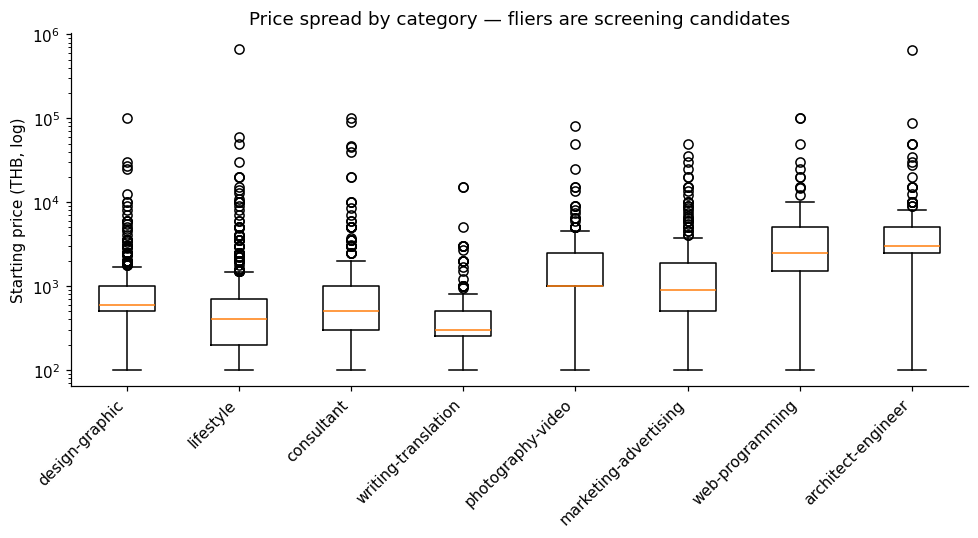

In [3]:
# price distribution per category (log scale) makes the outliers obvious
cats = df['category_slug'].value_counts().head(8).index
data = [df.loc[df['category_slug']==c,'price_min'].dropna() for c in cats]
fig, ax = plt.subplots(figsize=(9,5))
ax.boxplot(data, labels=cats, vert=True, showfliers=True)
ax.set_yscale('log'); ax.set_ylabel('Starting price (THB, log)')
ax.set_title('Price spread by category — fliers are screening candidates')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 2. Which rules actually fire? (an honest audit)

Running every rule against the real sample surfaces a methodological finding, not just a
result: most fraud heuristics are **dormant** here, and *why* matters.

In [4]:
hit = pd.Series([f for fl in res['flags'] for f in fl]).value_counts()
print('Rule hit counts on the live sample:')
print(hit.to_string() if len(hit) else 'none')

pc, rc = df['purchase_count'].fillna(0), df['rating_count'].fillna(0)
print('\n--- why the other rules are silent ---')
print('gigs with >=10 sales but 0 reviews :', int(((pc>=10)&(rc==0)).sum()), '(review counts are internally consistent)')
print('gigs with reviews but 0 sales      :', int(((rc>0)&(pc==0)).sum()), '(reviews are tied to real orders)')
sgc = df['seller_hash'].map(df['seller_hash'].value_counts())
print('max gigs per seller in sample      :', int(sgc.max()), '(random sampling scatters each seller -> spam signal needs targeted collection)')

Rule hit counts on the live sample:
EXTREME_PRICE    14

--- why the other rules are silent ---
gigs with >=10 sales but 0 reviews : 0 (review counts are internally consistent)
gigs with reviews but 0 sales      : 0 (reviews are tied to real orders)
max gigs per seller in sample      : 6 (random sampling scatters each seller -> spam signal needs targeted collection)


> **Takeaway.** On a *random* market sample, only the price-outlier and multivariate signals
> are observable. Seller-spam and fake-review detection would require **targeted** collection
> (all gigs of a suspect seller) — a sampling-strategy insight worth more than a fake-looking
> high recall number.

## 3. IsolationForest — multivariate oddness (and its catch)

The model flags gigs whose *combination* of features is unusual. Crucially, "unusual"
captures both bad actors **and** standout performers — so it is a triage aid, never a verdict.

In [5]:
iso = res.sort_values('iforest_score', ascending=False).head(10)
iso[['category_slug','price_min','purchase_count','rating_count','seller_gig_count','iforest_score']]

,category_slug,price_min,purchase_count,rating_count,seller_gig_count,iforest_score
1712,photography-video,7990.0,326.0,202.0,1,0.791271
365,marketing-advertising,400.0,456.0,285.0,2,0.789758
42,marketing-advertising,580.0,1685.0,955.0,1,0.777490
1660,design-graphic,400.0,127.0,74.0,2,0.763973
2646,writing-translation,300.0,178.0,147.0,1,0.763761
2601,design-graphic,900.0,344.0,189.0,1,0.762383
2206,writing-translation,250.0,88.0,73.0,1,0.758158
1615,marketing-advertising,699.0,138.0,62.0,1,0.756727
445,marketing-advertising,700.0,90.0,72.0,1,0.746897
913,design-graphic,500.0,95.0,50.0,2,0.738293


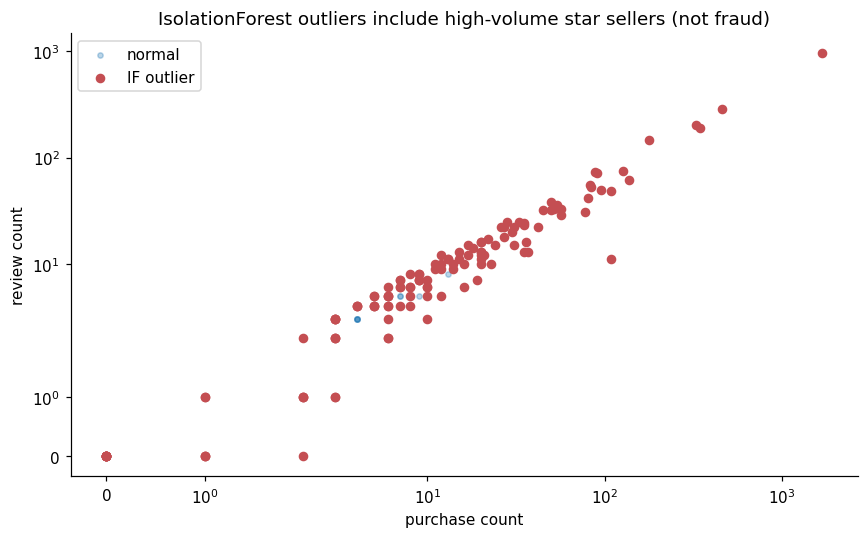

In [6]:
# colour gigs by IsolationForest outlier flag: note the star sellers in the top-right
fig, ax = plt.subplots(figsize=(8,5))
m = res['iforest_outlier']
ax.scatter(res.loc[~m,'purchase_count'], res.loc[~m,'rating_count'], s=12, alpha=.3, label='normal')
ax.scatter(res.loc[m,'purchase_count'], res.loc[m,'rating_count'], s=28, color='#C44E52', label='IF outlier')
ax.set_xlabel('purchase count'); ax.set_ylabel('review count')
ax.set_xscale('symlog'); ax.set_yscale('symlog')
ax.set_title('IsolationForest outliers include high-volume star sellers (not fraud)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. The screener output

Final composite ranking — rule hits dominate, IsolationForest breaks ties — each row carrying
a plain-language reason a human reviewer can act on.

In [7]:
res.head(12)[['category_slug','price_min','purchase_count','rating_count','n_flags','reason']]

,category_slug,price_min,purchase_count,rating_count,n_flags,reason
2233,writing-translation,15000.0,8.0,6.0,1,starting price is a wild outlier for its categ...
2611,design-graphic,100000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
2056,writing-translation,15000.0,0.0,0.0,1,starting price is a wild outlier for its categ...
974,lifestyle,666666.0,NaN,NaN,1,starting price is a wild outlier for its categ...
1217,architect-engineer,650000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
1398,design-graphic,30000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
1923,design-graphic,27000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
413,design-graphic,25000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
10,technician,2000000.0,NaN,NaN,1,starting price is a wild outlier for its categ...
293,lifestyle,60300.0,0.0,0.0,1,starting price is a wild outlier for its categ...


## How a trust team would use this — and what's next

- **Use as triage**, not enforcement: the top of the list is a daily review queue, not an
  auto-ban list. Every item is explained, so a reviewer decides in seconds.
- **Price outliers** are the immediate win — placeholder/manipulated prices are unambiguous.
- **To unlock the dormant signals**, collect *targeted* data: pull every gig of a flagged
  seller to activate spam/duplication detection, and join order-level data (not public) to
  test review authenticity.
- **With labels** (a trust team's historical actions), the same features feed a supervised
  model — this notebook is the feature-engineering and sanity-check groundwork for that.

*Anonymized, aggregated, public data only. Anomaly ≠ guilt — see README Ethics & Compliance.*